# Laboratorio #5 — Agentes en el Arcade Learning Environment (ALE): Space Invaders

**CC3092 — Deep Learning y Sistemas Inteligentes**

Este notebook deja funcionando la infraestructura de código para que un agente **sin entrenamiento**
(aleatorio o basado en una regla simple) interactúe con un entorno de Atari a través de ALE y genere
un video de la partida. El mismo módulo será la base para entrenar agentes en el proyecto futuro.

El módulo de funciones vive en [`ale_utils.py`](ale_utils.py); aquí se documenta y se ejercita.

## Entorno de ejecución

```bash
python -m venv .venv
.venv/Scripts/activate          # Windows
pip install -r requirements.txt
```

El notebook debe correr con el kernel **Python (Lab5-DL)**, que apunta al `.venv` del proyecto.

In [1]:
import sys
from pathlib import Path

import numpy as np
import gymnasium as gym
import ale_py

print("Python     ", sys.version.split()[0])
print("Gymnasium  ", gym.__version__)
print("ale-py     ", ale_py.__version__)
print("NumPy      ", np.__version__)

Python      3.11.9
Gymnasium   1.3.0
ale-py      0.12.1
NumPy       2.4.6


---
# Parte 1 — El Arcade Learning Environment (ALE)

Los cuatro puntos de investigación se desarrollan a fondo en el PDF entregable. Resumen operativo:

**Qué es ALE.** El *Arcade Learning Environment* es un framework que expone los juegos del Atari 2600
como problemas de aprendizaje por refuerzo, con una interfaz uniforme (observación, acción, recompensa,
fin de episodio). Resuelve el problema de la evaluación: antes de ALE cada investigador probaba su
agente en su propio dominio hecho a la medida, lo que hacía imposible comparar resultados. ALE ofrece
+100 juegos distintos, con dinámicas variadas pero una **misma interfaz y un mismo espacio de acción
crudo**, lo que obliga a los algoritmos a ser generales en vez de estar afinados a un dominio.

**Relación con Stella.** ALE no reimplementa los juegos: es una capa sobre **Stella**, un emulador de
Atari 2600 de código abierto. Stella ejecuta la ROM original del cartucho; ALE se conecta a él para
leer la pantalla y los 128 bytes de RAM, inyectar las pulsaciones del joystick y extraer el marcador
del juego como señal de recompensa. Por eso la dinámica es fiel al juego comercial de 1978/1980.

**Variantes de un mismo juego.** Ver la tabla comparativa que se genera más abajo.

**Frame skipping.** Ver la sección dedicada más abajo.

In [2]:
# Registrar el namespace "ALE/..." en Gymnasium.
gym.register_envs(ale_py)

env = gym.make("ALE/SpaceInvaders-v5")
print("Entorno:", env.spec.id)
print("Parámetros por defecto de la variante v5:")
for k, v in sorted(env.spec.kwargs.items()):
    print(f"   {k:28s} = {v}")
env.close()

Entorno: ALE/SpaceInvaders-v5
Parámetros por defecto de la variante v5:
   frameskip                    = 4
   full_action_space            = False
   game                         = space_invaders
   max_num_frames_per_episode   = 108000
   repeat_action_probability    = 0.25


### Variantes del mismo juego

`ALE/SpaceInvaders-v5` es solo una configuración de la ROM. Los ejes que la definen:

| Eje | Valores | Efecto |
|---|---|---|
| `obs_type` | `"rgb"` (default), `"grayscale"`, `"ram"` | Imagen 210×160×3, imagen 210×160, o los 128 bytes de RAM de la consola |
| `frameskip` | `4` en v5 | Cada acción se repite durante *k* frames del emulador |
| `repeat_action_probability` | `0.25` en v5 | *Sticky actions*: con esa probabilidad el emulador ignora la acción nueva y repite la anterior |
| `full_action_space` | `False` en v5 | `False` → solo las 6 acciones que el juego usa; `True` → las 18 acciones del joystick |
| `mode` / `difficulty` | enteros | Selectores de las variantes internas del cartucho original |

El punto crítico de **v5 frente a v4** es `repeat_action_probability=0.25`. Sin ella, el Atari es
totalmente determinista: un agente puede memorizar una secuencia fija de acciones y obtener un puntaje
altísimo sin haber aprendido nada de la dinámica del juego. Las *sticky actions* inyectan estocasticidad
en la transición y hacen que el agente tenga que ser robusto. Es la razón por la que los resultados
publicados sobre v4 y v5 **no son comparables entre sí**.

In [3]:
variantes = [
    ("ALE/SpaceInvaders-v5",  {}),
    ("ALE/SpaceInvaders-v5",  {"obs_type": "ram"}),
    ("ALE/SpaceInvaders-v5",  {"obs_type": "grayscale"}),
    ("ALE/SpaceInvaders-v5",  {"full_action_space": True}),
    ("ALE/SpaceInvaders-v5",  {"frameskip": 1, "repeat_action_probability": 0.0}),
]

print(f"{'kwargs':52s} {'observation_space':26s} {'action_space'}")
print("-" * 105)
for nombre, kw in variantes:
    e = gym.make(nombre, **kw)
    etiqueta = str(kw) if kw else "{} (defaults v5)"
    print(f"{etiqueta:52s} {str(e.observation_space):26s} {e.action_space}")
    e.close()

kwargs                                               observation_space          action_space
---------------------------------------------------------------------------------------------------------


{} (defaults v5)                                     Box(0, 255, (210, 160, 3), uint8) Discrete(6)


{'obs_type': 'ram'}                                  Box(0, 255, (128,), uint8) Discrete(6)


{'obs_type': 'grayscale'}                            Box(0, 255, (210, 160), uint8) Discrete(6)


{'full_action_space': True}                          Box(0, 255, (210, 160, 3), uint8) Discrete(18)


{'frameskip': 1, 'repeat_action_probability': 0.0}   Box(0, 255, (210, 160, 3), uint8) Discrete(6)


### Frame skipping

Con `frameskip=k` el agente elige una acción y el emulador la mantiene durante *k* frames, devolviendo
solo el último y la **suma** de las recompensas de esos frames. Importa por tres razones:

1. **Costo de cómputo.** Con `k=4` se toma una decisión cada 4 frames: la red neuronal se evalúa 4 veces
   menos, y el episodio se simula ~4× más rápido. Es la diferencia entre entrenar en horas o en días.
2. **Horizonte temporal.** El Atari corre a 60 Hz; a esa frecuencia una acción individual casi no cambia
   nada y la asignación de crédito se vuelve muy difusa (el agente tendría que propagar la recompensa
   cientos de pasos atrás). Con `k=4` el agente decide a ~15 Hz, comparable al ritmo humano, y cada
   decisión tiene una consecuencia visible.
3. **Control fino.** Un `k` demasiado grande impide reaccionar a tiempo. `k=4` es el valor estándar
   desde el DQN de Nature; en Space Invaders es además el valor donde los disparos se ven consistentemente
   (con otros valores el parpadeo del sprite del láser puede hacerlo invisible en el frame muestreado).

Comprobación empírica del efecto en velocidad:

In [4]:
import time

for k in (1, 4, 8):
    e = gym.make("ALE/SpaceInvaders-v5", frameskip=k)
    e.reset(seed=0)
    t0, pasos_agente = time.perf_counter(), 300
    for _ in range(pasos_agente):
        _, _, term, trunc, _ = e.step(e.action_space.sample())
        if term or trunc:
            e.reset()
    dt = time.perf_counter() - t0
    e.close()
    print(f"frameskip={k}: {pasos_agente} decisiones = {pasos_agente*k:>5d} frames emulados "
          f"en {dt:.2f}s  ->  {pasos_agente/dt:6.1f} decisiones/s")

frameskip=1: 300 decisiones =   300 frames emulados en 0.17s  ->  1740.5 decisiones/s


frameskip=4: 300 decisiones =  1200 frames emulados en 0.54s  ->   559.1 decisiones/s


frameskip=8: 300 decisiones =  2400 frames emulados en 1.03s  ->   292.3 decisiones/s


### Space Invaders: mecánica y recompensa

El jugador controla un cañón láser en la base de la pantalla que solo se mueve horizontalmente y puede
disparar hacia arriba. Enfrente hay una formación de 6×6 invasores que se desplaza lateralmente y baja
una fila cada vez que toca un borde, acelerando conforme quedan menos. Cuatro búnkeres destructibles dan
cobertura parcial. El objetivo es eliminar la formación completa antes de que los invasores lleguen abajo;
el jugador tiene **3 vidas** y el episodio termina al perderlas todas.

La recompensa del entorno es exactamente el **incremento del marcador del juego original** entre pasos
consecutivos: ALE lee el score de la RAM y devuelve la diferencia. Esto significa que:

- la recompensa es **dispersa**: casi todos los pasos dan `0.0`, y solo los aciertos puntúan;
- su magnitud depende de la fila del invasor (**5, 10, 15, 20, 25, 30** puntos según la fila; la nave
  nodriza roja que cruza arriba vale entre 50 y 200);
- **no hay penalización negativa** por perder una vida — la única señal es positiva, y el costo de morir
  es implícito (se acaba el episodio y ya no se puede seguir puntuando).

El `return` no descontado de un episodio es entonces el puntaje final de la partida.

---
# Parte 2 — Espacios de observación y acción

In [5]:
env = gym.make("ALE/SpaceInvaders-v5")
cart = gym.make("CartPole-v1")

print("ALE/SpaceInvaders-v5")
print("   observation_space:", env.observation_space)
print("   dimensionalidad  :", int(np.prod(env.observation_space.shape)), "valores por observación")
print("   action_space     :", env.action_space)
print()
print("CartPole-v1 (laboratorio anterior)")
print("   observation_space:", cart.observation_space)
print("   dimensionalidad  :", int(np.prod(cart.observation_space.shape)), "valores por observación")
print("   action_space     :", cart.action_space)
print()
print("Razón de dimensionalidad:",
      int(np.prod(env.observation_space.shape)) // int(np.prod(cart.observation_space.shape)), "x")
cart.close(); env.close()

ALE/SpaceInvaders-v5
   observation_space: Box(0, 255, (210, 160, 3), uint8)
   dimensionalidad  : 100800 valores por observación
   action_space     : Discrete(6)

CartPole-v1 (laboratorio anterior)
   observation_space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
   dimensionalidad  : 4 valores por observación
   action_space     : Discrete(2)

Razón de dimensionalidad: 25200 x


### Imagen vs. vector de bajo nivel

`CartPole-v1` entrega un `Box(4,)` de `float32` — posición, velocidad, ángulo y velocidad angular — es
decir, **el estado verdadero del sistema, ya extraído**. `ALE/SpaceInvaders-v5` entrega un `Box(210,160,3)`
de `uint8`: 100 800 valores de píxel crudos. Implicaciones:

- **Percepción como parte del problema.** El agente no recibe "hay un invasor en (x, y)"; recibe píxeles y
  tiene que aprender él mismo a detectar los objetos relevantes. Por eso los agentes de Atari son redes
  **convolucionales** y no MLPs pequeños: hay que aprender la representación además de la política.
- **Observabilidad parcial.** Un solo frame es una foto estática: no dice si un invasor baja o si un
  proyectil sube o cae. El estado no es markoviano respecto a una sola observación — de ahí el
  apilamiento de frames.
- **Costo.** Cada observación pesa ~100 KB. Un replay buffer de 1 M transiciones sería inviable sin
  preprocesamiento (de ahí 84×84 en escala de grises: ~7 KB, y con almacenamiento `uint8`).
- **Muestras necesarias.** CartPole se resuelve en miles de pasos; los agentes de Atari necesitan
  decenas de millones de frames.

### La variante RAM (`obs_type="ram"`)

Expone directamente los **128 bytes** de memoria de la consola: un `Box(0, 255, (128,), uint8)` donde
cada byte es una variable interna del juego (posiciones, contadores, vidas, marcador). Conviene cuando:

- se quiere **aislar el problema de control** del de visión, para estudiar el algoritmo de RL sin cargar
  con el costo de una CNN;
- hay **poco presupuesto de cómputo**: un MLP sobre 128 bytes entrena órdenes de magnitud más rápido;
- se necesita **diagnóstico o *reward shaping***: identificando qué byte guarda qué, se puede construir
  una señal auxiliar o verificar el comportamiento del agente.

Su desventaja es que la representación es opaca y arbitraria (los bytes no tienen semántica documentada
y varían por juego), y que se aleja del planteamiento original de ALE — aprender desde la misma entrada
sensorial que ve un humano.

In [6]:
e_ram = gym.make("ALE/SpaceInvaders-v5", obs_type="ram")
obs, _ = e_ram.reset(seed=0)
print("observation_space:", e_ram.observation_space)
print("observación (128 bytes):")
print(obs.reshape(8, 16))
e_ram.close()

observation_space: Box(0, 255, (128,), uint8)
observación (128 bytes):
[[  0   7   0  68 241 162  34 183  68  13 124 255 255  50 255 255]
 [  0  36  63  63  63  63  63  63  82   0  23  43  35 117 180   0]
 [ 36  63  63  63  63  63  63 110   0  23   1  60 126 126 126 126]
 [255 255 255 195  60 126 126 126 126 255 255 255 195  60 126 126]
 [126 126 255 255 255 195   0   0  48   3 129   0   0   0   0   0]
 [  0 246 246  63  63 246 246  63  63   0  21  24   0  52  82 196]
 [246  20   7   0 226   0   0   0   0   0  21  63   0 128 171   0]
 [255   0 189   0   0   0   0   0  99 255   0   0 235 254 192 242]]


### Espacio de acción

Space Invaders usa por defecto el **espacio reducido**: `Discrete(6)`, solo las acciones que la ROM
interpreta. Con `full_action_space=True` se expone el joystick completo del Atari 2600 (`Discrete(18)`),
donde las 12 acciones adicionales son redundantes en este juego (el cañón no se mueve verticalmente).

In [7]:
env = gym.make("ALE/SpaceInvaders-v5")
significados = {
    "NOOP":      "no hacer nada; el cañón queda donde está",
    "FIRE":      "disparar sin desplazarse",
    "RIGHT":     "desplazar el cañón a la derecha",
    "LEFT":      "desplazar el cañón a la izquierda",
    "RIGHTFIRE": "desplazarse a la derecha y disparar en el mismo paso",
    "LEFTFIRE":  "desplazarse a la izquierda y disparar en el mismo paso",
}
print(env.action_space, "\n")
for i, nombre in enumerate(env.unwrapped.get_action_meanings()):
    print(f"  {i}  {nombre:10s} {significados[nombre]}")

print()
e_full = gym.make("ALE/SpaceInvaders-v5", full_action_space=True)
print(e_full.action_space, "->", e_full.unwrapped.get_action_meanings())
e_full.close(); env.close()

Discrete(6) 

  0  NOOP       no hacer nada; el cañón queda donde está
  1  FIRE       disparar sin desplazarse
  2  RIGHT      desplazar el cañón a la derecha
  3  LEFT       desplazar el cañón a la izquierda
  4  RIGHTFIRE  desplazarse a la derecha y disparar en el mismo paso
  5  LEFTFIRE   desplazarse a la izquierda y disparar en el mismo paso



Discrete(18) -> ['NOOP', 'FIRE', 'UP', 'RIGHT', 'LEFT', 'DOWN', 'UPRIGHT', 'UPLEFT', 'DOWNRIGHT', 'DOWNLEFT', 'UPFIRE', 'RIGHTFIRE', 'LEFTFIRE', 'DOWNFIRE', 'UPRIGHTFIRE', 'UPLEFTFIRE', 'DOWNRIGHTFIRE', 'DOWNLEFTFIRE']


Las acciones compuestas (`RIGHTFIRE`, `LEFTFIRE`) son las más útiles en la práctica: permiten esquivar y
disparar en el mismo paso de decisión. El agente de regla simple de este laboratorio las usa para eso.

### `AtariPreprocessing` y `FrameStackObservation`

`gymnasium.wrappers.AtariPreprocessing` es el wrapper que estandariza el pipeline del DQN de Nature.
Aplica:

| Transformación | Para qué |
|---|---|
| **Escala de grises** | El color no aporta información de control; reduce el tensor a 1/3 |
| **Redimensionar a 84×84** | Baja de 100 800 a 7 056 valores por frame |
| **Frame skipping** (`frame_skip=4`) | Menos decisiones por segundo de juego |
| **Max-pooling de los 2 últimos frames** | El Atari alterna sprites entre frames por límite de hardware; sin esto algunos objetos **parpadean y desaparecen** |
| **`noop_max=30`** | Reinicia con un número aleatorio de NOOPs, para que el agente no memorice un inicio fijo |
| **Recorte de recompensa** (`scale_obs` / clipping externo) | Lleva la recompensa a `{-1, 0, +1}`, para usar los mismos hiperparámetros en juegos con escalas de puntaje muy distintas |

`FrameStackObservation` (antes `FrameStack`) apila las **k últimas observaciones** en un solo tensor
(`(4, 84, 84)`). Se usa junto con `AtariPreprocessing` porque resuelve exactamente el problema de
observabilidad parcial señalado antes: un frame aislado no contiene velocidad ni dirección. Con 4 frames
apilados el agente puede inferir que un proyectil **sube** o que la formación **baja**, y el estado vuelve
a ser aproximadamente markoviano.

> Nota: `AtariPreprocessing` hace su propio frame skipping, así que el entorno base debe crearse con
> `frameskip=1` para no multiplicar los saltos.

In [8]:
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation

base = gym.make("ALE/SpaceInvaders-v5", frameskip=1)   # frameskip=1: lo maneja el wrapper
print("base                    :", base.observation_space)

prep = AtariPreprocessing(base, frame_skip=4, screen_size=84, grayscale_obs=True)
print("+ AtariPreprocessing    :", prep.observation_space)

apilado = FrameStackObservation(prep, stack_size=4)
print("+ FrameStackObservation :", apilado.observation_space)

obs, _ = apilado.reset(seed=0)
print()
print("observación final:", obs.shape, obs.dtype)
print("reducción de tamaño:",
      f"{np.prod((210,160,3))/np.prod(obs.shape[1:]):.1f}x por frame")
apilado.close()

base                    : Box(0, 255, (210, 160, 3), uint8)
+ AtariPreprocessing    : Box(0, 255, (84, 84), uint8)
+ FrameStackObservation : Box(0, 255, (4, 84, 84), uint8)



observación final: (4, 84, 84) uint8
reducción de tamaño: 14.3x por frame


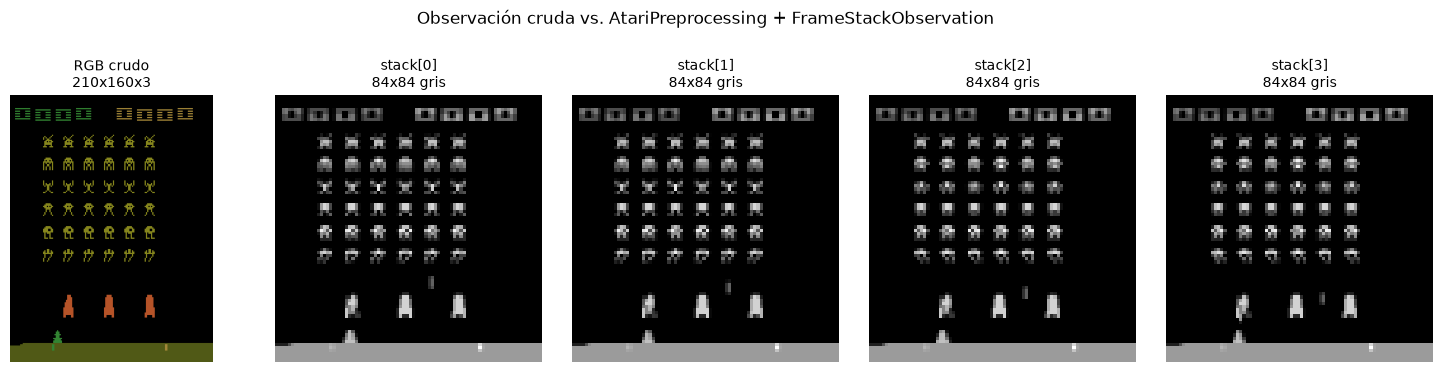

In [9]:
import matplotlib.pyplot as plt

# Comparación visual: frame RGB crudo vs. los 4 frames preprocesados y apilados
base = gym.make("ALE/SpaceInvaders-v5", frameskip=1)
env_prep = FrameStackObservation(
    AtariPreprocessing(base, frame_skip=4, screen_size=84, grayscale_obs=True), stack_size=4
)
env_prep.reset(seed=0)
for _ in range(60):
    obs_stack, *_ = env_prep.step(env_prep.action_space.sample())

env_rgb = gym.make("ALE/SpaceInvaders-v5")
obs_rgb, _ = env_rgb.reset(seed=0)
for _ in range(60):
    obs_rgb, *_ = env_rgb.step(0)

fig, axes = plt.subplots(1, 5, figsize=(15, 3.6))
axes[0].imshow(obs_rgb)
axes[0].set_title("RGB crudo\n210x160x3", fontsize=10)
for i in range(4):
    axes[i + 1].imshow(obs_stack[i], cmap="gray")
    axes[i + 1].set_title(f"stack[{i}]\n84x84 gris", fontsize=10)
for a in axes:
    a.axis("off")
fig.suptitle("Observación cruda vs. AtariPreprocessing + FrameStackObservation", y=1.02)
plt.tight_layout(); plt.show()

env_prep.close(); env_rgb.close()

---
# Parte 3 — Módulo de funciones para interactuar con ALE

El módulo está en [`ale_utils.py`](ale_utils.py). Contiene:

| Función | Rol |
|---|---|
| `crear_entorno(nombre_entorno, render_mode, video_folder, name_prefix, episode_trigger, **kwargs)` | Crea el entorno de Gymnasium. Si se pasa `video_folder`, lo envuelve con `RecordVideo`. Genérica: sirve para cualquier entorno, no solo Atari. |
| `agente_aleatorio(observation, env)` | Baseline sin entrenamiento: `env.action_space.sample()`. |
| `agente_regla_simple(observation, env)` | Heurística sobre píxeles, en dos niveles: esquiva el proyectil inminente si lo hay; si no, se alinea con el invasor más cercano y dispara. |
| `ejecutar_episodio(env, funcion_agente, max_steps=10000, seed=None)` | Corre un episodio hasta `terminated`/`truncated` o `max_steps`; retorna pasos y recompensa total. |
| `generar_video_agente(nombre_entorno, funcion_agente, video_folder, name_prefix, n_episodios=1)` | Alto nivel: crea el entorno con grabación, corre los episodios, hace `env.close()` y retorna rutas de video + métricas. |
| `resumir_metricas(metricas)` | Utilidad de reporte. |

Decisiones de diseño que vale la pena señalar:

- **`env.close()` va dentro de un `finally`.** `RecordVideo` escribe el `.mp4` al cerrar el entorno; si
  un episodio lanza una excepción y no se cierra, el archivo queda vacío o truncado.
- **`generar_video_agente` toma un *snapshot* de la carpeta antes de correr** y reporta solo los archivos
  nuevos, de modo que reejecutar la celda no acumule videos viejos en el resultado.
- **`agente_regla_simple` degrada a aleatorio** si la observación no es un frame RGB de 210×160×3
  (p. ej. `obs_type="ram"`) o si el espacio de acción no expone `FIRE`/`LEFTFIRE`/`RIGHTFIRE`. Así el
  módulo nunca revienta al usarse con otro entorno.
- **Las acciones se resuelven por nombre**, vía `env.unwrapped.get_action_meanings()`, no por índice
  fijo: la heurística sigue funcionando con `full_action_space=True`, donde los índices cambian.
- **`ejecutar_episodio` siembra también el `action_space`.** `env.reset(seed=s)` solo fija el generador
  del entorno; `action_space.sample()` tiene el suyo propio. Sin sembrarlo, una corrida de
  `agente_aleatorio` no sería reproducible.

### Cómo funciona `agente_regla_simple`

La heurística lee tres sprites del frame RGB por color exacto (constantes del emulador, obtenidas
inspeccionando los frames):

| Sprite | Color RGB | Filas |
|---|---|---|
| Nave del jugador | `(50, 132, 50)` | 180–195 |
| Invasores | `(134, 134, 29)` | 25–160 |
| Proyectiles | `(142, 142, 142)` | toda la zona de juego |

La nave se busca solo en las filas bajas porque **el marcador usa exactamente el mismo verde** en la
parte superior de la pantalla; sin acotar la banda, el centroide quedaría contaminado.

Con eso, la regla es:

1. **Esquivar** — si hay un proyectil en la franja 140–178 (justo encima de la nave) a menos de 4
   columnas de ella, moverse al lado contrario, disparando.
2. **Apuntar** — si no hay peligro inmediato, alinearse con la columna del invasor vivo más cercano y
   disparar; `LEFTFIRE`/`RIGHTFIRE` permiten moverse y disparar en el mismo paso.

El paso 1 es el que hace la diferencia. La primera versión de esta heurística solo apuntaba, y quedaba
**por debajo del agente aleatorio**: alinearse con una columna de invasores deja a la nave exactamente
en la trayectoria de las bombas que esa columna deja caer, así que moría mucho antes (≈390 pasos contra
≈490 del aleatorio). Añadir el esquive invirtió el resultado.

Una limitación honesta: el láser del jugador y las bombas de los invasores **comparten color**, así que
un disparo propio recién lanzado puede leerse como amenaza. El efecto resultó benigno — provoca que la
nave se mueva después de disparar, que es justo lo que conviene hacer.

In [10]:
from ale_utils import (
    crear_entorno,
    agente_aleatorio,
    agente_regla_simple,
    ejecutar_episodio,
    generar_video_agente,
    resumir_metricas,
    ACCIONES_SPACE_INVADERS,
)

CARPETA_VIDEOS = Path("videos")
print("Módulo cargado. Acciones de Space Invaders:")
for i, nombre in ACCIONES_SPACE_INVADERS.items():
    print(f"   {i} -> {nombre}")

Módulo cargado. Acciones de Space Invaders:
   0 -> NOOP
   1 -> FIRE
   2 -> RIGHT
   3 -> LEFT
   4 -> RIGHTFIRE
   5 -> LEFTFIRE


## Prueba de las funciones por separado

Antes de generar los videos, se verifica cada función de forma aislada.

In [11]:
# 1) crear_entorno sin video, sobre un entorno que NO es Atari (genericidad)
env = crear_entorno("CartPole-v1")
resultado = ejecutar_episodio(env, agente_aleatorio, seed=0)
env.close()
print("CartPole-v1  ->", f"pasos={resultado['pasos']}, return={resultado['recompensa_total']}")

# 2) agente_aleatorio: distribución de acciones muestreadas
env = crear_entorno("ALE/SpaceInvaders-v5")
env.reset(seed=0)
acciones = [agente_aleatorio(None, env) for _ in range(6000)]
conteo = np.bincount(acciones, minlength=6)
print("\nagente_aleatorio, 6000 muestras (esperado ~1000 c/u):")
for i, n in enumerate(conteo):
    print(f"   {ACCIONES_SPACE_INVADERS[i]:10s} {n:5d}")
env.close()

CartPole-v1  -> pasos=18, return=18.0



agente_aleatorio, 6000 muestras (esperado ~1000 c/u):
   NOOP         935
   FIRE        1005
   RIGHT       1035
   LEFT         974
   RIGHTFIRE   1011
   LEFTFIRE    1040


In [12]:
# 3) ejecutar_episodio: max_steps corta el episodio y lo reporta
env = crear_entorno("ALE/SpaceInvaders-v5")
r = ejecutar_episodio(env, agente_aleatorio, max_steps=50, seed=0)
env.close()
print("con max_steps=50 ->", {k: v for k, v in r.items() if k != "info"})

# 4) reproducibilidad: la misma semilla da exactamente el mismo episodio
env = crear_entorno("ALE/SpaceInvaders-v5")
a = ejecutar_episodio(env, agente_aleatorio, seed=7)
b = ejecutar_episodio(env, agente_aleatorio, seed=7)
env.close()
print(f"\nseed=7 dos veces -> ({a['pasos']}, {a['recompensa_total']}) "
      f"y ({b['pasos']}, {b['recompensa_total']})  ->  reproducible: "
      f"{(a['pasos'], a['recompensa_total']) == (b['pasos'], b['recompensa_total'])}")

con max_steps=50 -> {'pasos': 50, 'recompensa_total': 0.0, 'terminated': False, 'truncated': False, 'limite_alcanzado': True}



seed=7 dos veces -> (436, 30.0) y (436, 30.0)  ->  reproducible: True


### Qué "ve" el agente de regla simple

Para verificar que la detección por color es correcta, se marca sobre un frame real lo que la heurística
extrae: el centroide de la nave, las columnas con invasores vivos y los proyectiles dentro de la zona de
peligro.

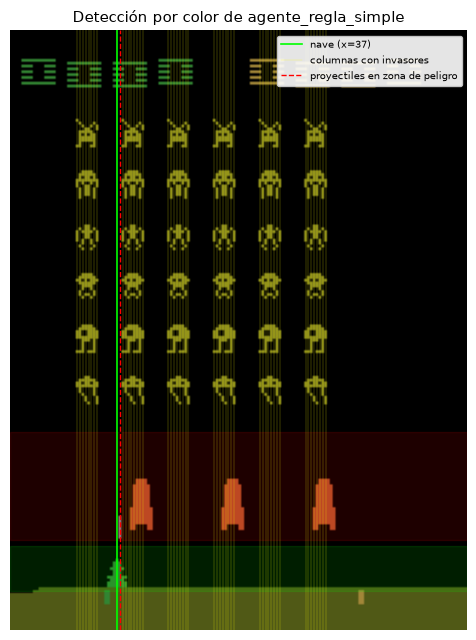

acción elegida en este frame: LEFTFIRE


In [13]:
from ale_utils import (
    _COLOR_NAVE, _COLOR_ALIENS, _COLOR_PROYECTIL,
    _FILAS_NAVE, _FILAS_ALIENS, _FILAS_PELIGRO,
    _columnas_de_color,
)

# Avanzar hasta encontrar un frame con proyectiles en pantalla.
env = crear_entorno("ALE/SpaceInvaders-v5")
obs, _ = env.reset(seed=5)
for _ in range(400):
    obs, *_ = env.step(agente_regla_simple(obs, env))
    if _columnas_de_color(obs, _FILAS_PELIGRO, _COLOR_PROYECTIL).size:
        break
env.close()

x_nave = _columnas_de_color(obs, _FILAS_NAVE, _COLOR_NAVE).mean()
cols_aliens = _columnas_de_color(obs, _FILAS_ALIENS, _COLOR_ALIENS)
cols_balas = _columnas_de_color(obs, _FILAS_PELIGRO, _COLOR_PROYECTIL)

fig, ax = plt.subplots(figsize=(5.5, 6.5))
ax.imshow(obs)
ax.axvline(x_nave, color="lime", lw=1.2, label=f"nave (x={x_nave:.0f})")
for i, c in enumerate(cols_aliens):
    ax.axvline(c, color="yellow", lw=.35, alpha=.5,
               label="columnas con invasores" if i == 0 else None)
for i, c in enumerate(cols_balas):
    ax.axvline(c, color="red", lw=1.0, ls="--",
               label="proyectiles en zona de peligro" if i == 0 else None)
ax.axhspan(_FILAS_PELIGRO.start, _FILAS_PELIGRO.stop, color="red", alpha=.12)
ax.axhspan(_FILAS_NAVE.start, _FILAS_NAVE.stop, color="lime", alpha=.12)
ax.set_title("Detección por color de agente_regla_simple", fontsize=11)
ax.legend(loc="upper right", fontsize=7.5, framealpha=.9)
ax.axis("off")
plt.tight_layout(); plt.show()

env_aux = crear_entorno("ALE/SpaceInvaders-v5")
print("acción elegida en este frame:",
      ACCIONES_SPACE_INVADERS[agente_regla_simple(obs, env_aux)])
env_aux.close()

---
## Generación de los videos

### Video 1 — agente aleatorio en `ALE/SpaceInvaders-v5` (entregable obligatorio)

In [14]:
videos_aleatorio, metricas_aleatorio = generar_video_agente(
    nombre_entorno="ALE/SpaceInvaders-v5",
    funcion_agente=agente_aleatorio,
    video_folder=CARPETA_VIDEOS,
    name_prefix="aleatorio-spaceinvaders",
    n_episodios=1,
    seed=42,
)

print(resumir_metricas(metricas_aleatorio))
print()
for v in videos_aleatorio:
    print("video generado:", v, f"({Path(v).stat().st_size/1024:.0f} KB)")

C:\Users\antho\Desktop\Lab5-DL\.venv\Lib\site-packages\gymnasium\wrappers\rendering.py:292: UserWarning: WARN: Overwriting existing videos at C:\Users\antho\Desktop\Lab5-DL\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Episodio |   Pasos | Recompensa
---------+---------+-----------
       0 |     325 |       65.0

video generado: videos\aleatorio-spaceinvaders-episode-0.mp4 (71 KB)


In [15]:
m = metricas_aleatorio[0]
print("=" * 58)
print("  VIDEO 1 — AGENTE ALEATORIO — ALE/SpaceInvaders-v5")
print("=" * 58)
print(f"  Archivo             : {Path(videos_aleatorio[0]).name}")
print(f"  Pasos sobrevividos  : {m['pasos']}")
print(f"  Recompensa total    : {m['recompensa_total']:.1f}")
print(f"  Episodio terminado  : terminated={m['terminated']}, truncated={m['truncated']}")
print(f"  Vidas restantes     : {m['info'].get('lives')}")
print(f"  Frames del emulador : {m['info'].get('episode_frame_number')}")
print("=" * 58)

  VIDEO 1 — AGENTE ALEATORIO — ALE/SpaceInvaders-v5
  Archivo             : aleatorio-spaceinvaders-episode-0.mp4
  Pasos sobrevividos  : 325
  Recompensa total    : 65.0
  Episodio terminado  : terminated=True, truncated=False
  Vidas restantes     : 0
  Frames del emulador : 1297


### Video 2 — agente de regla simple en `ALE/SpaceInvaders-v5`

In [16]:
videos_regla, metricas_regla = generar_video_agente(
    nombre_entorno="ALE/SpaceInvaders-v5",
    funcion_agente=agente_regla_simple,
    video_folder=CARPETA_VIDEOS,
    name_prefix="regla-simple-spaceinvaders",
    n_episodios=1,
    seed=42,
)

print(resumir_metricas(metricas_regla))
print()
m = metricas_regla[0]
print("=" * 58)
print("  VIDEO 2 — AGENTE REGLA SIMPLE — ALE/SpaceInvaders-v5")
print("=" * 58)
print(f"  Archivo             : {Path(videos_regla[0]).name}")
print(f"  Pasos sobrevividos  : {m['pasos']}")
print(f"  Recompensa total    : {m['recompensa_total']:.1f}")
print("=" * 58)

Episodio |   Pasos | Recompensa
---------+---------+-----------
       0 |     460 |      215.0

  VIDEO 2 — AGENTE REGLA SIMPLE — ALE/SpaceInvaders-v5
  Archivo             : regla-simple-spaceinvaders-episode-0.mp4
  Pasos sobrevividos  : 460
  Recompensa total    : 215.0


### Video 3 — varios episodios y `episode_trigger`

`generar_video_agente` acepta `n_episodios > 1`; `crear_entorno` permite además filtrar cuáles grabar
mediante `episode_trigger`, útil durante un entrenamiento largo donde no se quiere un `.mp4` por episodio.

In [17]:
videos_multi, metricas_multi = generar_video_agente(
    nombre_entorno="ALE/SpaceInvaders-v5",
    funcion_agente=agente_aleatorio,
    video_folder=CARPETA_VIDEOS,
    name_prefix="aleatorio-3-episodios",
    n_episodios=3,
    seed=100,
)

print(resumir_metricas(metricas_multi))
print()
for v in videos_multi:
    print("  ", Path(v).name)

Episodio |   Pasos | Recompensa
---------+---------+-----------
       0 |     408 |       65.0
       1 |     383 |      110.0
       2 |     432 |       30.0
---------+---------+-----------
   media |   407.7 |       68.3

   aleatorio-3-episodios-episode-0.mp4
   aleatorio-3-episodios-episode-1.mp4
   aleatorio-3-episodios-episode-2.mp4


In [18]:
# episode_trigger: grabar solo los episodios pares
env = crear_entorno(
    "ALE/SpaceInvaders-v5",
    video_folder=CARPETA_VIDEOS,
    name_prefix="solo-episodios-pares",
    episode_trigger=lambda episode_id: episode_id % 2 == 0,
)
try:
    for i in range(4):
        r = ejecutar_episodio(env, agente_aleatorio, max_steps=200, seed=i)
        print(f"episodio {i}: pasos={r['pasos']:4d}  return={r['recompensa_total']:6.1f}")
finally:
    env.close()

print()
print("Videos escritos (solo 0 y 2):")
for v in sorted(CARPETA_VIDEOS.glob("solo-episodios-pares*.mp4")):
    print("  ", v.name)

episodio 0: pasos= 200  return=  20.0


episodio 1: pasos= 200  return=  30.0


episodio 2: pasos= 200  return=  30.0


episodio 3: pasos= 200  return=  55.0

Videos escritos (solo 0 y 2):
   solo-episodios-pares-episode-0.mp4
   solo-episodios-pares-episode-2.mp4


---
## Comparación: aleatorio vs. regla simple

Un solo episodio no dice mucho, porque la varianza en Atari es alta (y v5 tiene *sticky actions*).
Se corren 10 semillas por agente **sin grabar video** para comparar.

In [19]:
def evaluar(funcion_agente, n=10, semilla_base=100):
    env = crear_entorno("ALE/SpaceInvaders-v5", render_mode=None)
    try:
        return [ejecutar_episodio(env, funcion_agente, seed=semilla_base + i) for i in range(n)]
    finally:
        env.close()

res_aleatorio = evaluar(agente_aleatorio)
res_regla = evaluar(agente_regla_simple)

for nombre, res in [("aleatorio", res_aleatorio), ("regla simple", res_regla)]:
    r = [x["recompensa_total"] for x in res]
    p = [x["pasos"] for x in res]
    print(f"{nombre:14s} return: media={np.mean(r):6.1f}  std={np.std(r):5.1f}  "
          f"min={min(r):5.1f}  max={max(r):5.1f}   |   pasos: media={np.mean(p):6.1f}")

aleatorio      return: media= 115.0  std= 49.8  min= 30.0  max=225.0   |   pasos: media= 445.8
regla simple   return: media= 239.5  std= 56.8  min=110.0  max=320.0   |   pasos: media= 522.7


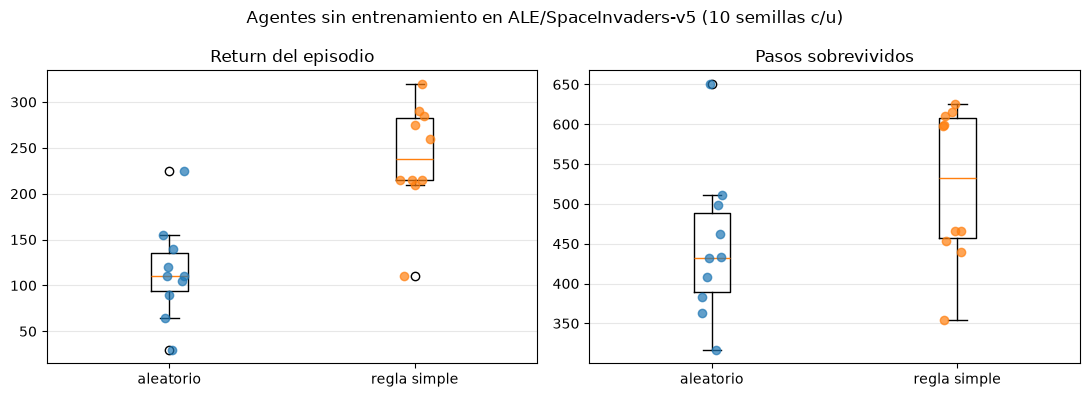

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
datos = {
    "aleatorio": [x["recompensa_total"] for x in res_aleatorio],
    "regla simple": [x["recompensa_total"] for x in res_regla],
}
pasos = {
    "aleatorio": [x["pasos"] for x in res_aleatorio],
    "regla simple": [x["pasos"] for x in res_regla],
}

for ax, d, titulo in [(axes[0], datos, "Return del episodio"),
                      (axes[1], pasos, "Pasos sobrevividos")]:
    ax.boxplot(d.values(), tick_labels=list(d.keys()))
    for i, vals in enumerate(d.values(), start=1):
        ax.scatter(np.full(len(vals), i) + np.random.uniform(-.06, .06, len(vals)),
                   vals, alpha=.7, zorder=3)
    ax.set_title(titulo)
    ax.grid(axis="y", alpha=.3)

fig.suptitle("Agentes sin entrenamiento en ALE/SpaceInvaders-v5 (10 semillas c/u)")
plt.tight_layout(); plt.show()

El agente de regla simple **duplica** el return medio del aleatorio con una desviación estándar
comparable en términos absolutos, es decir, bastante más consistente en términos relativos (coeficiente
de variación ≈0.24 contra ≈0.43). Eso confirma que el pipeline —observación → decisión → acción →
recompensa— está bien conectado: la política *sí* está leyendo el frame y actuando en consecuencia,
que es todo el objetivo del laboratorio.

Conviene no leer de más en el número. Ninguno de los dos agentes **aprende**: la heurística tiene el
conocimiento del juego cableado a mano por el programador, y no mejoraría ni corriendo un millón de
episodios. Ambos quedan además muy por debajo de un DQN entrenado (~600–1000 puntos) o de un humano
(~1650). El valor de la regla simple aquí es servir de prueba de que la infraestructura funciona, y de
segundo punto de referencia además del aleatorio.

---
## Videos generados

Todos los `.mp4` quedan en la carpeta `videos/`, que forma parte de los entregables.

In [21]:
print(f"{'archivo':44s} {'KB':>7}")
print("-" * 53)
for v in sorted(CARPETA_VIDEOS.glob("*.mp4")):
    print(f"{v.name:44s} {v.stat().st_size/1024:7.0f}")

archivo                                           KB
-----------------------------------------------------
aleatorio-3-episodios-episode-0.mp4               93
aleatorio-3-episodios-episode-1.mp4               86
aleatorio-3-episodios-episode-2.mp4               96
aleatorio-spaceinvaders-episode-0.mp4             71
regla-simple-spaceinvaders-episode-0.mp4         104
solo-episodios-pares-episode-0.mp4                47
solo-episodios-pares-episode-2.mp4                49


In [22]:
from IPython.display import Video, display

# Reproducción inline del entregable obligatorio.
display(Video(videos_aleatorio[0], embed=True, width=420))

---
## Resumen de resultados

Tabla consolidada de todos los videos entregados, con los pasos sobrevividos y la recompensa total de
cada episodio (requisito del enunciado).

In [23]:
from IPython.display import Markdown, display

filas = []
for v, m in zip(videos_aleatorio, metricas_aleatorio):
    filas.append((Path(v).name, "aleatorio", m))
for v, m in zip(videos_regla, metricas_regla):
    filas.append((Path(v).name, "regla simple", m))
for v, m in zip(videos_multi, metricas_multi):
    filas.append((Path(v).name, "aleatorio", m))

tabla = ["| Video | Agente | Pasos sobrevividos | Recompensa total |",
         "|---|---|---:|---:|"]
for nombre, agente, m in filas:
    tabla.append(f"| `{nombre}` | {agente} | {m['pasos']} | {m['recompensa_total']:.0f} |")

display(Markdown("\n".join(tabla)))

| Video | Agente | Pasos sobrevividos | Recompensa total |
|---|---|---:|---:|
| `aleatorio-spaceinvaders-episode-0.mp4` | aleatorio | 325 | 65 |
| `regla-simple-spaceinvaders-episode-0.mp4` | regla simple | 460 | 215 |
| `aleatorio-3-episodios-episode-0.mp4` | aleatorio | 408 | 65 |
| `aleatorio-3-episodios-episode-1.mp4` | aleatorio | 383 | 110 |
| `aleatorio-3-episodios-episode-2.mp4` | aleatorio | 432 | 30 |

Con esto queda funcionando la infraestructura pedida: creación de entornos ALE (y de cualquier entorno
de Gymnasium), ejecución de episodios con una función de agente intercambiable, reporte de métricas y
grabación de video en disco. Sustituir `funcion_agente` por la política de una red entrenada es el único
cambio necesario para reutilizar todo esto en el proyecto.